Plot Charts

In [2]:
# same similarity configs
SIM_METRICS = ["cosine", "dot", "L2"]

# ---- HNSW parameters ----
# number of neighbors in the graph (higher => better recall, more memory)
HNSW_M = 32

# construction quality (higher => better graph, slower build)
HNSW_EF_CONSTRUCTION = 200

# search breadth (higher => better recall, slower search)
HNSW_EF_SEARCH = 64

OUT_XLSX = "faiss_hnsw_results.xlsx"

C:\Users\Alire\AppData\Local\Temp\ipykernel_28796\2635981903.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95], pad=0.25)


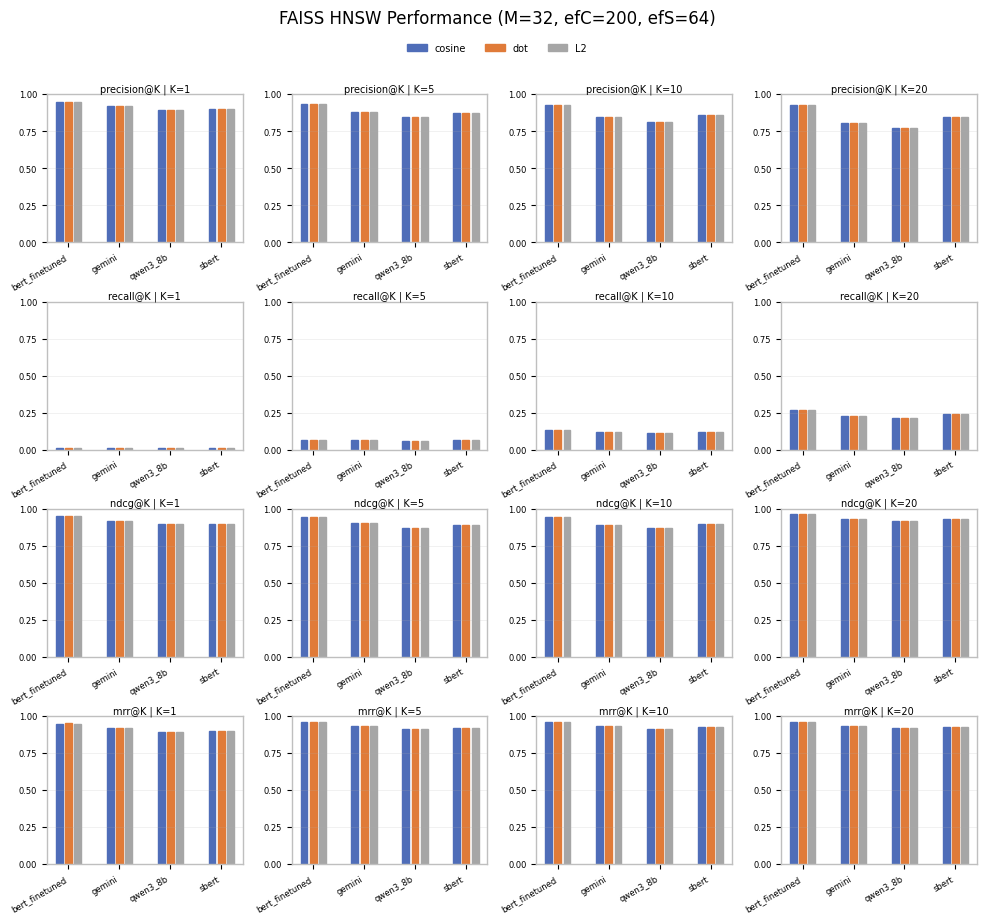

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULT_XLSX = OUT_XLSX  # "faiss_hnsw_results.xlsx"
df = pd.read_excel(RESULT_XLSX, sheet_name="Summary", engine="openpyxl")

# فقط HNSW method
df = df[df["method"].astype(str).str.contains("faiss_hnsw", case=False, na=False)].copy()
df["K"] = df["K"].astype(int)

K_LIST = [1, 5, 10, 20]
df = df[df["K"].isin(K_LIST)]

score_cols = ["precision@K", "recall@K", "ndcg@K", "mrr@K"]

colors = ["#4F6DB8", "#E07B39", "#A6A6A6"]  # blue, orange, gray
metric_order = ["cosine", "dot", "L2"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#BFBFBF",
    "axes.linewidth": 1.0,
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 7
})

fig, axes = plt.subplots(
    4, 4,
    figsize=(12, 10),
    gridspec_kw={"hspace": 0.40, "wspace": 0.25}
)

fig.suptitle(
    f"FAISS HNSW Performance (M={HNSW_M}, efC={HNSW_EF_CONSTRUCTION}, efS={HNSW_EF_SEARCH})",
    fontsize=12, y=0.965
)

legend_handles, legend_labels = None, None

ymin, ymax = 0.0, 1.0
yticks = np.linspace(0, 1, 5)

for row, score_col in enumerate(score_cols):
    for col, K_FIXED in enumerate(K_LIST):
        ax = axes[row, col]
        sub = df[df["K"] == K_FIXED]

        pivot = sub.pivot_table(
            index="embedding",
            columns="metric",
            values=score_col,
            aggfunc="mean"
        ).sort_index()

        embeddings = pivot.index.tolist()
        sim_metrics = [m for m in metric_order if m in pivot.columns.tolist()]
        if not sim_metrics:
            sim_metrics = pivot.columns.tolist()

        x = np.arange(len(embeddings))
        bar_w = 0.18

        for j, met in enumerate(sim_metrics):
            ax.bar(
                x + (j - (len(sim_metrics) - 1) / 2) * bar_w,
                pivot[met].values,
                width=bar_w * 0.75,
                color=colors[j % len(colors)],
                edgecolor=colors[j % len(colors)],
                label=str(met)
            )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.set_title(f"{score_col} | K={K_FIXED}", pad=2)
        ax.set_xticks(x)
        ax.set_xticklabels(embeddings, rotation=30, ha="right")

        ax.set_ylim(ymin, ymax)
        ax.set_yticks(yticks)

        ax.grid(True, axis="y", linewidth=0.5, alpha=0.25)
        ax.grid(False, axis="x")

if legend_handles and legend_labels:
    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncol=len(legend_labels),
        frameon=False,
        bbox_to_anchor=(0.5, 0.94)
    )

plt.tight_layout(rect=[0, 0, 1, 0.95], pad=0.25)
plt.show()

In [ ]:
FIG_NAME = "FAISS_HNSW_Performance_HQ.png"

fig.savefig(
    FIG_NAME,
    dpi=600,              
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: FAISS_IVFPQ_Performance_HQ.png


only NGCD and accuracy (cosine similarity)

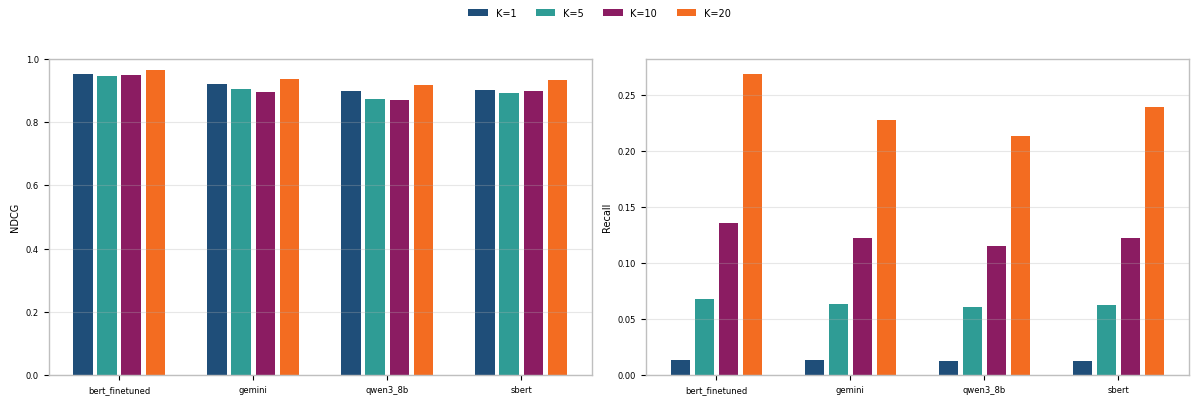

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# فایل نتایج
XLSX = "faiss_hnsw_results.xlsx"
SHEET = "Summary"

K_LIST = [1, 5, 10, 20]

# خواندن داده
df = pd.read_excel(XLSX, sheet_name=SHEET, engine="openpyxl")

# فقط cosine
df = df[df["metric"].astype(str).str.lower() == "cosine"].copy()
df["K"] = df["K"].astype(int)
df = df[df["K"].isin(K_LIST)]

# pivot tables
pivot_ndcg = df.pivot_table(index="embedding", columns="K", values="ndcg@K", aggfunc="mean").sort_index()
pivot_recall = df.pivot_table(index="embedding", columns="K", values="recall@K", aggfunc="mean").sort_index()

embeddings = pivot_ndcg.index.tolist()
x = np.arange(len(embeddings))
bar_w = 0.18

# رنگ‌ها مطابق نمونه
colors = ["#1f4e79", "#2f9c95", "#8b1c62", "#f36c21"]

# شکل شامل دو نمودار
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---------- NDCG ----------
ax = axes[0]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1) / 2) * bar_w,
        pivot_ndcg[K].values,
        # width=bar_w,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )
# ax.set_title("FAISS HNSW (Graph-based) — NDCG@K (cosine)")
ax.set_ylabel("NDCG")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

# ---------- Recall ----------
ax = axes[1]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1) / 2) * bar_w,
        pivot_recall[K].values,
        # width=bar_w,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )
# ax.set_title("FAISS HNSW (Graph-based) — Recall@K (cosine)")
ax.set_ylabel("Recall")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")
ax.grid(axis="y", alpha=0.3)

# legend مشترک
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [ ]:
FIG_NAME = "FAISS_HNSW_NDGC_Accuracy_cosine.png"

fig.savefig(
    FIG_NAME,
    dpi=600,              
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: FAISS_HNSW_NDGC_Accuracy_cosine.png
